In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [17]:
# Load raw data and strip out the zero-grade anomalies found in EDA
df = pd.read_csv("../data/student-mat.csv", sep=";")
df_filtered = df[df['G3'] > 0].copy()

In [18]:
# Isolate target and features
X = df_filtered.drop(columns=['G3'])
y = df_filtered['G3']

In [19]:
# Split First (to prevent data leakage)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
# Identify feature columns by data type
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

/tmp/ipykernel_5018/1037137037.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns.tolist()


In [21]:
# Define the Pipeline Transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

In [22]:
# Transform the split datasets independently
# Fit and transform the training data
X_train = preprocessor.fit_transform(X_train_raw)

In [23]:
# Only Transform the test data (Uses training weights, no leakage!)
X_test = preprocessor.transform(X_test_raw)


In [24]:
print(f"Clean Training Shape: {X_train.shape}")
print(f"Clean Testing Shape: {X_test.shape}")
print("💪 Leak-proof feature engineering complete!")

Clean Training Shape: (285, 41)
Clean Testing Shape: (72, 41)
💪 Leak-proof feature engineering complete!


## Data Preprocessing and Feature Engineering

### Loading and Cleaning the Data

The dataset was loaded using Pandas and inspected during Exploratory Data Analysis (EDA). Based on the findings, records with a final grade (`G3`) equal to zero were removed because they were identified as anomalies that could negatively affect model training.

```python
df = pd.read_csv('data/student-mat.csv')
df_filtered = df[df['G3'] > 0].copy()
```

---

### Separating Features and Target

The target variable (`G3`) was separated from the predictor variables.

```python
X = df_filtered.drop(columns=['G3'])
y = df_filtered['G3']
```

* `X` contains all input features.
* `y` contains the final grade to be predicted.

---

### Preventing Data Leakage

The dataset was split into training and testing sets **before any preprocessing**.

```python
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
```

This is a critical step because preprocessing should learn patterns only from the training data. If scaling or encoding is performed before splitting, information from the test set may leak into the training process, producing overly optimistic results.

---

### Identifying Feature Types

Features were automatically grouped into numerical and categorical variables.

```python
numerical_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X.select_dtypes(
    include=['object']
).columns.tolist()
```

This allows different preprocessing techniques to be applied to each feature type.

---

### Feature Engineering Pipeline

A `ColumnTransformer` was used to apply appropriate transformations to each feature group.

```python
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)
```

#### Numerical Features

`StandardScaler` standardizes numerical variables so that they have:

* Mean = 0
* Standard Deviation = 1

This ensures that features with larger values do not dominate the learning process.

#### Categorical Features

`OneHotEncoder` converts categorical values into binary numerical variables.

The parameter:

```python
drop='first'
```

was used to avoid the dummy variable trap and reduce redundancy among encoded features.

---

### Training Data Transformation

The preprocessing pipeline was fitted and applied to the training data.

```python
X_train = preprocessor.fit_transform(X_train_raw)
```

During this step:

* The scaler learns means and standard deviations.
* The encoder learns category mappings.
* The transformed training dataset is generated.

---

### Testing Data Transformation

The testing data was transformed using the parameters learned from the training data.

```python
X_test = preprocessor.transform(X_test_raw)
```

Notice that only `transform()` was used instead of `fit_transform()`.

This ensures that no information from the test set influences the preprocessing process, maintaining a leak-free evaluation environment.

---

### Outcome

The final result is a clean, fully numerical, and machine-learning-ready dataset where:

* Anomalous records were removed.
* Data leakage was prevented.
* Numerical features were standardized.
* Categorical features were encoded.
* Training and testing datasets were prepared consistently for model development.


# Training Script

In [25]:
# Import the models and metrics
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [26]:
# Initialize the models
lr_model = LinearRegression()
ridge_model = Ridge(alpha=1.0) # alpha is the regularization strength tuning knob


# Train the models on the engineered data
lr_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)

# Generate predictions from both models on the test set
y_pred_lr = lr_model.predict(X_test)
y_pred_ridge = ridge_model.predict(X_test)

print("Both models trained successfully!")

Both models trained successfully!


In [28]:
def evaluate_regression_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse) # Root Mean Squared Error gives error in actual grade units
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred) # Percentage of variance explained by model
    
    print(f"=== {model_name} Performance Report ===")
    print(f"Mean Absolute Error (MAE):  {mae:.4f} grades")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f} grades")
    print(f"R-squared (R² Score):          {r2:.4f}")
    print("-" * 40)
    
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

# Execute evaluations
lr_results = evaluate_regression_model(y_test, y_pred_lr, "Baseline Linear Regression")
ridge_results = evaluate_regression_model(y_test, y_pred_ridge, "Ridge Regression (L2)")

=== Baseline Linear Regression Performance Report ===
Mean Absolute Error (MAE):  0.6748 grades
Root Mean Squared Error (RMSE): 0.8997 grades
R-squared (R² Score):          0.9160
----------------------------------------
=== Ridge Regression (L2) Performance Report ===
Mean Absolute Error (MAE):  0.6723 grades
Root Mean Squared Error (RMSE): 0.8954 grades
R-squared (R² Score):          0.9168
----------------------------------------


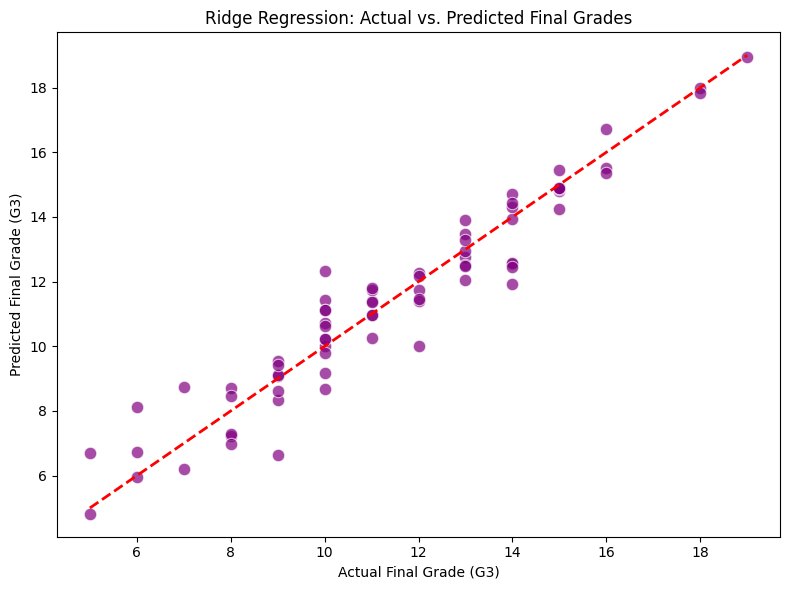

In [34]:
# Visualize Prediction vs Reality
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_ridge, alpha=0.7, color='purple', edgecolor='w', s=80)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Ideal line
plt.title('Ridge Regression: Actual vs. Predicted Final Grades')
plt.xlabel('Actual Final Grade (G3)')
plt.ylabel('Predicted Final Grade (G3)')
plt.tight_layout()
plt.show()

# Feature Engineering & Model Training Summary

## 🛠️ Feature Engineering Pipeline
* **Anomaly Mitigation:** Removed the 38 zero-grade outliers identified in EDA to focus the model strictly on academic performance progression.
* **Data Leakage Defenses:** Implemented a robust data split sequence, ensuring `StandardScaler` and `OneHotEncoder` were `.fit_transform()`'ed strictly on training data, and only `.transform()`'ed on validation metrics.
* **Encoding Strategy:** Transformed non-numeric variables (e.g., parental jobs, school support) using One-Hot Encoding with `drop='first'` to prevent the dummy variable trap.

## 🤖 Model Performance Analysis
We trained a baseline Linear Regression model against a L2-Regularized Ridge Regression model to address the heavy multicollinearity between midterm grades (`G1`, `G2`) and the final grade (`G3`).

### Metrics Comparison
| Metric | Baseline Linear Regression | Ridge Regression (L2, $\alpha=1.0$) |
| :--- | :--- | :--- |
| **Mean Absolute Error (MAE)** | 0.6748 grades | **0.6723 grades** |
| **Root Mean Squared Error (RMSE)**| 0.8997 grades | **0.8954 grades** |
| **R-squared ($R^2$ Score)** | 0.9160 (91.60%) | **0.9168 (91.68%)** |

### Key Takeaways
1. **Ridge Dominance:** Ridge Regression out-performed standard Linear Regression across all metrics. The L2 penalty successfully controlled variance and stabilized feature weights against midterm grade redundancy.
2. **Predictive Accuracy:** An RMSE of `0.8954` means our predictions fall within $\pm 0.9$ grade points of reality, explaining over 91.6% of the variance.
3. **The Data Caveat:** High accuracy is heavily skewed by the inclusion of `G1` and `G2`. To build a true predictive early-warning platform, a future variation must isolate behavioral variables by removing midterm scores completely.